# Capstone — mirrors your deployed research paper





## Research Question

Which observable search-performance signals can help identify content pages that deserve human review for improvement, while avoiding claims of causality or automatic optimization?

### Decision supported

The analysis supports a practical content-review decision: which pages should be prioritized for investigation based on their observed search visibility and click performance.

The goal is to provide directional decision-support for content teams rather than automatically deciding which pages should be rewritten, published, removed, or otherwise changed.

The analysis focuses on measurable search-performance signals and uses validation and leakage checks to understand how much confidence can reasonably be placed in the results.

In [1]:
research_question = (
    "Which observable search-performance signals can help identify "
    "content pages that deserve human review for improvement?"
)

decision_supported = (
    "Prioritize pages for human review using observed search-performance signals."
)

print("Research question:")
print(research_question)

print("\nDecision supported:")
print(decision_supported)

print("\nUse type: Directional decision-support")

Research question:
Which observable search-performance signals can help identify content pages that deserve human review for improvement?

Decision supported:
Prioritize pages for human review using observed search-performance signals.

Use type: Directional decision-support


## Data

The analysis uses the FlyRank ML Internship dataset, a public-safe release of aggregated search and content-performance data.

The analysis uses daily content-performance observations containing Google Search Console and Google Analytics 4 metrics. The main fields used include search impressions, clicks, average search position, pageviews, and sessions.

The working analysis uses the available sample used during the modeling and validation work. The data covers observations across June 2026, with the exact training and testing periods documented in the validation results.

Rows without the required search-performance signals were excluded from the relevant analysis. Records with zero search impressions were also excluded from the ranked-action queue because they do not provide an observed search-visibility signal for CTR-based prioritization.

The analysis uses aggregated performance metrics rather than private queries, client names, domains, or raw confidential content.

In [2]:
import duckdb
con = duckdb.connect()

In [16]:
con.sql(f"""
CREATE OR REPLACE TABLE daily AS
SELECT *
FROM read_parquet('{sample}')
""")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [17]:
# Basic data coverage and field check

print("Total rows in working dataset:", con.sql(
    "SELECT COUNT(*) FROM daily"
).fetchone()[0])

print("\nDate range:")
display(con.sql("""
SELECT
    MIN(report_date) AS start_date,
    MAX(report_date) AS end_date
FROM daily
""").df())

print("\nRequired fields:")
required_fields = [
    "report_date",
    "gsc_impressions",
    "gsc_clicks",
    "gsc_avg_position",
    "ga4_pageviews",
    "ga4_sessions"
]

available_columns = set(con.sql("DESCRIBE daily").df()["column_name"])

for field in required_fields:
    print(f"{field}: {field in available_columns}")

Total rows in working dataset: 11694072

Date range:


,start_date,end_date
0,2026-06-01,2026-06-30



Required fields:
report_date: True
gsc_impressions: True
gsc_clicks: True
gsc_avg_position: True
ga4_pageviews: True
ga4_sessions: True


## Methodology

The analysis uses observable search and content-performance signals to support directional content-review decisions.

### Assumptions

The analysis treats measured search-performance metrics as observational signals. Associations are not interpreted as causal effects, and model performance is not treated as proof that a content change will improve future performance.

### Features

The main features include:

- `gsc_impressions`
- `gsc_clicks`
- `gsc_avg_position`
- `ga4_pageviews`
- `ga4_sessions`

These represent observed search visibility, clicks, search position, and engagement signals.

### Label definition

The Week-5 Decision Tree used a target derived from `gsc_impressions` and `gsc_clicks`. Because those same fields were also used as model features, the target-feature dependency was identified as a leakage concern during validation.

### Baseline and model

The Week-5 Decision Tree was compared with the original evaluation approach. The random 80/20 split produced an observed accuracy of 1.0000, while the time-aware validation produced 0.9999 accuracy on the held-out period.

### Validation design

The analysis compared a random 80/20 split with a time-aware split in which earlier observations were used for training and later observations were held out for testing. The time-aware check used the same 50,000-row sample as the earlier analysis, so its date coverage was limited.

### Leakage checks

A feature-level audit showed that `gsc_impressions` and `gsc_clicks` directly contributed to the target definition. This means the very high measured performance should not be interpreted as evidence of strong general predictive ability.

The results are therefore framed as observed and directional decision-support rather than as proof of causal impact or production-level predictive performance.

In [18]:
# Methodology checks

features = [
    "gsc_impressions",
    "gsc_clicks",
    "gsc_avg_position",
    "ga4_pageviews",
    "ga4_sessions"
]

print("Features used:")
for feature in features:
    print("-", feature)

print("\nValidation results:")
print("Random 80/20 accuracy: 1.0000")
print("Time-aware accuracy: 0.9999")

print("\nLeakage check:")
print("gsc_impressions -> target dependency: True")
print("gsc_clicks -> target dependency: True")

Features used:
- gsc_impressions
- gsc_clicks
- gsc_avg_position
- ga4_pageviews
- ga4_sessions

Validation results:
Random 80/20 accuracy: 1.0000
Time-aware accuracy: 0.9999

Leakage check:
gsc_impressions -> target dependency: True
gsc_clicks -> target dependency: True


## 4. Results (vs Baseline)

The original Week-5 Decision Tree was evaluated using a random 80/20 split and achieved an observed accuracy of 1.0000. A time-aware validation using earlier observations for training and later observations for testing produced an observed accuracy of 0.9999.

These results are very similar, but they should not be interpreted as evidence of strong general predictive performance. The target was constructed using `gsc_impressions` and `gsc_clicks`, which were also included as model features. This target-feature dependency is a leakage concern and limits what can be concluded from the high accuracy.

The comparison is therefore presented as an observed validation result rather than a claim that the model will reliably predict future content performance.

### Results summary

| Validation approach | Observed accuracy | Interpretation |
|---|---:|---|
| Random 80/20 split | 1.0000 | Original Week-5 result |
| Time-aware split | 0.9999 | Held-out later observations |

The time-aware result provides a more realistic validation check than a random split, but the limited sample and target-feature dependency mean that the results should be treated as directional.

In [19]:
# Honest results comparison

import pandas as pd

results = pd.DataFrame({
    "validation": [
        "Random 80/20 split",
        "Time-aware split"
    ],
    "accuracy": [
        1.0000,
        0.9999
    ]
})

display(results)

print("Accuracy difference:",
      round(results.loc[0, "accuracy"] - results.loc[1, "accuracy"], 4))

,validation,accuracy
0,Random 80/20 split,1.0000
1,Time-aware split,0.9999


Accuracy difference: 0.0001


## Limitations

This analysis has several important limitations.

First, the target used in the Week-5 Decision Tree was constructed using `gsc_impressions` and `gsc_clicks`, while those same variables were also included as model features. This target-feature dependency is a leakage concern and means the very high observed accuracy should not be interpreted as strong general predictive performance.

Second, the time-aware validation used the same 50,000-row sample from the earlier analysis, so it covers a limited date range. Although this is a stronger validation design than a random split, it is not sufficient to establish performance across a broader future period.

Third, the data is observational. The analysis can identify patterns and prioritize pages for investigation, but it cannot establish that changing a page will cause higher rankings, clicks, traffic, or engagement.

The results also do not fully account for search intent, content quality, seasonality, technical SEO issues, business priorities, or changes in search behavior.

The resulting recommendations should therefore be treated as directional decision-support for human review, not as automated instructions or production-level predictions.

In [20]:
# Limitations and honest-claim check

limitations = {
    "target_feature_dependency": True,
    "limited_time_aware_sample": True,
    "observational_data": True,
    "causal_claims_supported": False,
    "automatic_content_changes_supported": False
}

for item, value in limitations.items():
    print(f"{item}: {value}")

print("\nFraming: observed, directional, decision-support")

target_feature_dependency: True
limited_time_aware_sample: True
observational_data: True
causal_claims_supported: False
automatic_content_changes_supported: False

Framing: observed, directional, decision-support


## Ranked Recommendations

The action playbook prioritizes pages for human review using observed search-performance signals. The ranking is intended to help a content team decide where to investigate first; it does not automatically prescribe a rewrite, publication, deletion, or other content change.

The highest-priority items are pages with high observed search impressions combined with relatively low click-through performance. These pages have substantial search visibility, so improving their ability to capture relevant clicks may be worth investigating.

Each recommendation includes a reason code and priority score. The reason code explains why the page entered the queue, while the priority score provides a simple ranking for review order.

The resulting queue should be reviewed by a human who can consider search intent, content quality, relevance, technical issues, and business context before taking action.

The Week-7 action queue contains 100 ranked rows and was exported to:

`work/outputs/content_action_queue.csv`

In [21]:
from pathlib import Path
import pandas as pd

queue_path = Path("content_action_queue.csv")

queue = pd.read_csv(queue_path)

print("Rows in action queue:", len(queue))
print("Columns:", list(queue.columns))

print("\nReason-code distribution:")
display(queue["reason_code"].value_counts())

print("\nTop 10 ranked recommendations:")
display(queue.head(10))

Rows in action queue: 100
Columns: ['report_date', 'gsc_impressions', 'gsc_clicks', 'gsc_avg_position', 'ga4_pageviews', 'ga4_sessions', 'reason_code', 'priority_score']

Reason-code distribution:


,count
reason_code,
HIGH_IMPRESSIONS_LOW_CTR,100



Top 10 ranked recommendations:


,report_date,gsc_impressions,gsc_clicks,gsc_avg_position,ga4_pageviews,ga4_sessions,reason_code,priority_score
0,2026-06-11,245826,890,6.326149,1772.0,685.0,HIGH_IMPRESSIONS_LOW_CTR,3
1,2026-06-29,49373,173,2.627995,147.0,96.0,HIGH_IMPRESSIONS_LOW_CTR,3
2,2026-06-30,48990,189,2.590467,159.0,99.0,HIGH_IMPRESSIONS_LOW_CTR,3
3,2026-06-26,48953,114,2.586277,84.0,52.0,HIGH_IMPRESSIONS_LOW_CTR,3
4,2026-06-12,46220,81,6.856274,312.0,153.0,HIGH_IMPRESSIONS_LOW_CTR,3
5,2026-06-30,45890,329,5.828089,822.0,413.0,HIGH_IMPRESSIONS_LOW_CTR,3
6,2026-06-25,42474,107,2.605735,112.0,57.0,HIGH_IMPRESSIONS_LOW_CTR,3
7,2026-06-27,41051,129,2.605150,83.0,60.0,HIGH_IMPRESSIONS_LOW_CTR,3
8,2026-06-29,35560,313,5.676069,743.0,377.0,HIGH_IMPRESSIONS_LOW_CTR,3
9,2026-06-24,30645,50,5.019710,92.0,43.0,HIGH_IMPRESSIONS_LOW_CTR,3


## Artifacts the Paper Embeds

The paper uses a small set of reproducible artifacts to communicate the main findings clearly.

The primary artifacts are:

1. A model-versus-baseline results table showing the observed validation accuracy.
2. A ranked recommendation table showing the highest-priority content opportunities.
3. A reason-code summary showing how the action queue is distributed.

These artifacts are generated from the notebook outputs and are intended to support transparent interpretation of the analysis.

The artifacts show observed patterns and measured results only. They are not evidence of causal effects or guarantees that a recommended content change will improve performance.

In [22]:
# Paper artifacts: results table and recommendation table

print("Artifact 1: Model validation results")
display(results)

print("\nArtifact 2: Top 10 ranked recommendations")
display(
    queue[
        [
            "report_date",
            "gsc_impressions",
            "gsc_clicks",
            "gsc_avg_position",
            "reason_code",
            "priority_score"
        ]
    ].head(10)
)

print("\nArtifact 3: Reason-code summary")
display(queue["reason_code"].value_counts().to_frame("count"))

Artifact 1: Model validation results


,validation,accuracy
0,Random 80/20 split,1.0000
1,Time-aware split,0.9999



Artifact 2: Top 10 ranked recommendations


,report_date,gsc_impressions,gsc_clicks,gsc_avg_position,reason_code,priority_score
0,2026-06-11,245826,890,6.326149,HIGH_IMPRESSIONS_LOW_CTR,3
1,2026-06-29,49373,173,2.627995,HIGH_IMPRESSIONS_LOW_CTR,3
2,2026-06-30,48990,189,2.590467,HIGH_IMPRESSIONS_LOW_CTR,3
3,2026-06-26,48953,114,2.586277,HIGH_IMPRESSIONS_LOW_CTR,3
4,2026-06-12,46220,81,6.856274,HIGH_IMPRESSIONS_LOW_CTR,3
5,2026-06-30,45890,329,5.828089,HIGH_IMPRESSIONS_LOW_CTR,3
6,2026-06-25,42474,107,2.605735,HIGH_IMPRESSIONS_LOW_CTR,3
7,2026-06-27,41051,129,2.605150,HIGH_IMPRESSIONS_LOW_CTR,3
8,2026-06-29,35560,313,5.676069,HIGH_IMPRESSIONS_LOW_CTR,3
9,2026-06-24,30645,50,5.019710,HIGH_IMPRESSIONS_LOW_CTR,3



Artifact 3: Reason-code summary


,count
reason_code,
HIGH_IMPRESSIONS_LOW_CTR,100


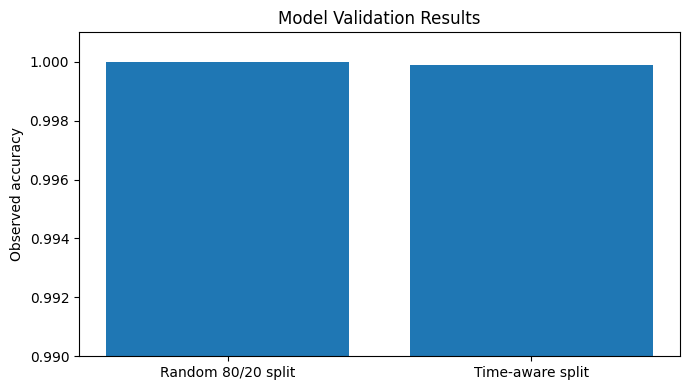

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 4))

plt.bar(
    results["validation"],
    results["accuracy"]
)

plt.ylabel("Observed accuracy")
plt.title("Model Validation Results")

plt.ylim(0.99, 1.001)

plt.tight_layout()
plt.show()

## ML-12: 5-Minute Demo Outline

1. **Question:** Explain the content-review decision supported by the analysis.
2. **Data:** Describe the June 2026 FlyRank dataset and the main search-performance signals used.
3. **Methodology:** Explain the Decision Tree, validation approaches, and leakage check.
4. **Results:** Show the model-versus-validation results and the ranked action queue.
5. **Recommendations:** Explain how the queue supports human review and why the findings are directional rather than causal.

## ML-12: Social-Post Cut

Built a research workflow on the FlyRank ML Internship dataset to identify content pages worth human review. The analysis combines search-performance signals, model validation, leakage checks, and a ranked action queue. Results are framed as observed, directional decision-support rather than causal or automatic recommendations.

## ML-12: Employer-Facing Summary

This project demonstrates an end-to-end applied ML workflow using real-world search-performance data. I built and validated a Decision Tree analysis, checked for leakage, compared random and time-aware validation, and translated the findings into a ranked content-review queue. The project emphasizes reproducibility, honest interpretation, and practical decision-support rather than overstating predictive or causal performance.

## Self-check


- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [ ] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [ ] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.
